#Assignment on Clustering


Try out different clustering models in the given dataset.

Find the optimum number
of clusters in each model and create the model with the optimum number of
clusters.

Please note the following:
Display the output for every action

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
data=pd.read_csv('/content/Wine_clust.csv')
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [25]:
data.shape

(178, 13)

In [26]:
data.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

In [27]:
data.isna().sum()

,0
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


In [28]:

X=data.iloc[:,[1,2]].values
X

array([[1.71, 2.43],
       [1.78, 2.14],
       [2.36, 2.67],
       [1.95, 2.5 ],
       [2.59, 2.87],
       [1.76, 2.45],
       [1.87, 2.45],
       [2.15, 2.61],
       [1.64, 2.17],
       [1.35, 2.27],
       [2.16, 2.3 ],
       [1.48, 2.32],
       [1.73, 2.41],
       [1.73, 2.39],
       [1.87, 2.38],
       [1.81, 2.7 ],
       [1.92, 2.72],
       [1.57, 2.62],
       [1.59, 2.48],
       [3.1 , 2.56],
       [1.63, 2.28],
       [3.8 , 2.65],
       [1.86, 2.36],
       [1.6 , 2.52],
       [1.81, 2.61],
       [2.05, 3.22],
       [1.77, 2.62],
       [1.72, 2.14],
       [1.9 , 2.8 ],
       [1.68, 2.21],
       [1.5 , 2.7 ],
       [1.66, 2.36],
       [1.83, 2.36],
       [1.53, 2.7 ],
       [1.8 , 2.65],
       [1.81, 2.41],
       [1.64, 2.84],
       [1.65, 2.55],
       [1.5 , 2.1 ],
       [3.99, 2.51],
       [1.71, 2.31],
       [3.84, 2.12],
       [1.89, 2.59],
       [3.98, 2.29],
       [1.77, 2.1 ],
       [4.04, 2.44],
       [3.59, 2.28],
       [1.68,

### Data Preprocessing and Scaling

In [29]:
# Select all numerical features for clustering
X = data.iloc[:, :].values

from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame for easier inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=data.columns)

print("First 5 rows of scaled data:")
display(X_scaled_df.head())

First 5 rows of scaled data:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### K-Means Clustering: Finding Optimal Clusters (Elbow Method)

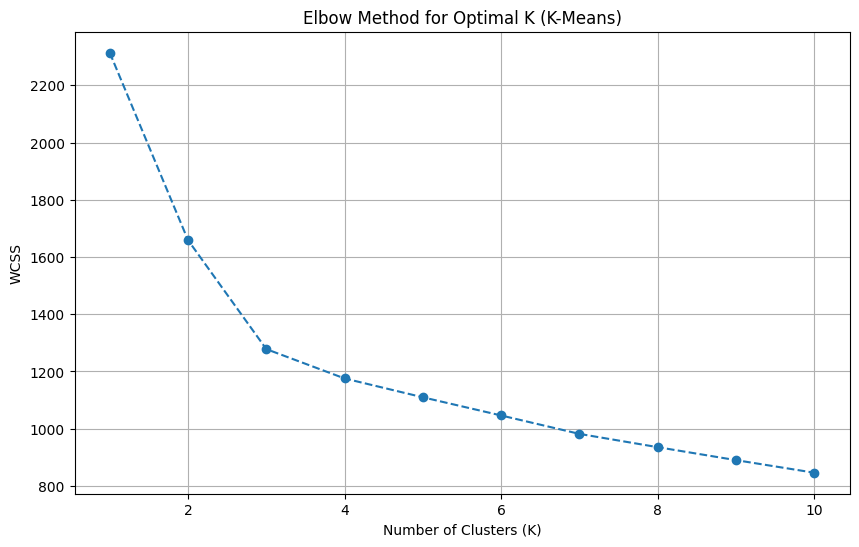

In [30]:
from sklearn.cluster import KMeans
wcss = [] # Within-Cluster Sum of Square

# Try K-Means for a range of cluster numbers (e.g., from 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Applying K-Means with Optimal Clusters

In [31]:
# Based on the elbow method, let's assume optimal K = 3
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Fit K-Means to the scaled data and get cluster labels
clusters = kmeans_optimal.fit_predict(X_scaled)

# Add the cluster labels to the original (scaled) DataFrame
X_scaled_df['Cluster'] = clusters

print(f"First 5 rows of scaled data with {optimal_k} clusters:")
display(X_scaled_df.head())

print(f"\nCluster distribution for {optimal_k} clusters:")
print(X_scaled_df['Cluster'].value_counts())

First 5 rows of scaled data with 3 clusters:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,2
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,2
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,2
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,2
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,2



Cluster distribution for 3 clusters:
Cluster
0    65
2    62
1    51
Name: count, dtype: int64


### Visualizing K-Means Clusters

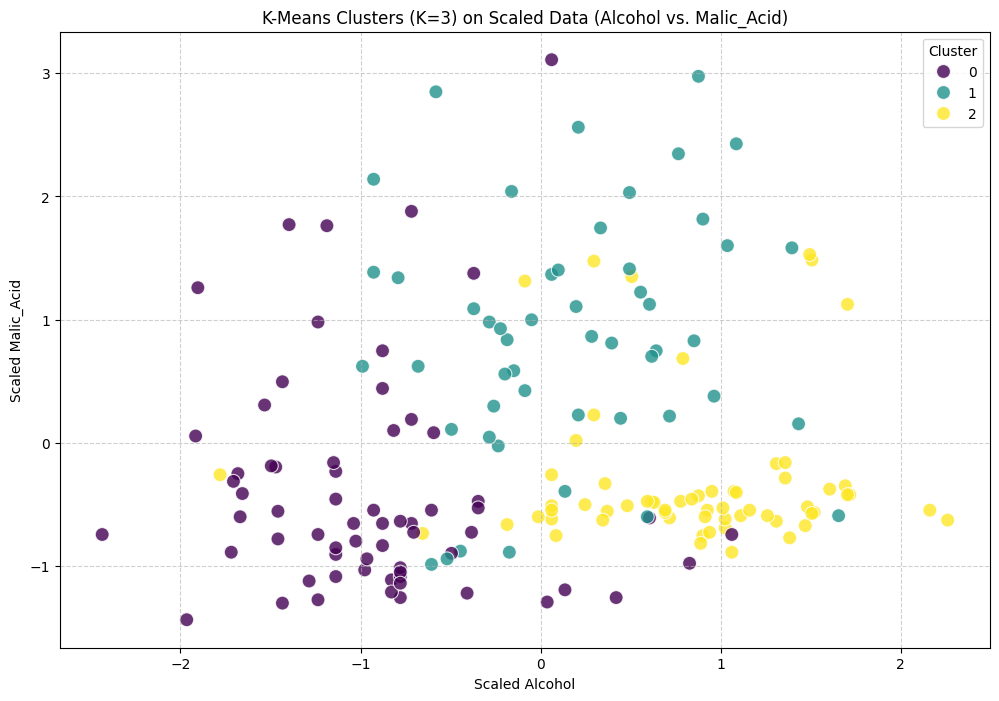

In [32]:
# Since we have many features, directly visualizing all dimensions is hard.
# For demonstration, let's pick two features (e.g., Alcohol and Malic_Acid) to visualize the clusters.
# In a real scenario, PCA or t-SNE would be used for dimensionality reduction for visualization.

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_scaled_df['Alcohol'],
    y=X_scaled_df['Malic_Acid'],
    hue=X_scaled_df['Cluster'],
    palette='viridis',
    s=100, # size of the points
    alpha=0.8
)
plt.title(f'K-Means Clusters (K={optimal_k}) on Scaled Data (Alcohol vs. Malic_Acid)')
plt.xlabel('Scaled Alcohol')
plt.ylabel('Scaled Malic_Acid')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()